# Week 8 Iteration Flash Results

This notebook presents the Week 8 iteration using expanded high-liquidity categories.

- Week 4 = prototype baseline milestone.
- Week 8 = expanded category universe with category-equal baseline.


In [1]:
from pathlib import Path
import json
import pandas as pd
import matplotlib.pyplot as plt

repo_root = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
processed = repo_root / "data" / "processed"
figures = repo_root / "figures"

baseline_metrics = json.loads((processed / "week8_baseline_metrics.json").read_text())
constrained_metrics = json.loads((processed / "week8_constrained_best_metrics.json").read_text())
quality = json.loads((processed / "week8_data_quality.json").read_text())
grid = pd.read_csv(processed / "week8_constrained_experiment_grid.csv")

print("markets:", quality["markets_count"])
print("categories:", len(quality["domain_coverage"]))


markets: 41
categories: 41


In [2]:
exposure = pd.Series(baseline_metrics["exposure_by_domain"]).sort_values(ascending=False)
exposure.head(), exposure.nunique()


(democratic-primary         0.02439
 world-elections            0.02439
 california-midterm         0.02439
 nba-champion               0.02439
 conference-championship    0.02439
 dtype: float64,
 1)

In [3]:
summary = pd.DataFrame([
    {
        "strategy": "week8_category_equal_baseline",
        "sortino": baseline_metrics["sortino_ratio"],
        "max_drawdown": baseline_metrics["max_drawdown"],
        "mean_return": baseline_metrics["mean_return"],
        "volatility": baseline_metrics["volatility"],
    },
    {
        "strategy": "week8_constrained_model",
        "sortino": constrained_metrics["best_params"]["sortino_ratio"],
        "max_drawdown": constrained_metrics["best_params"]["max_drawdown"],
        "mean_return": constrained_metrics["best_params"]["mean_return"],
        "volatility": constrained_metrics["best_params"]["volatility"],
    },
])
summary


,strategy,sortino,max_drawdown,mean_return,volatility
0,week8_category_equal_baseline,0.046551,-0.078397,0.000114,0.004539
1,week8_constrained_model,0.051650,-0.079158,0.000147,0.005251


In [4]:
grid.sort_values("sortino_ratio", ascending=False).head(10)


,learning_rate,lambda_penalty,rolling_window,max_weight,uniform_mix,sortino_ratio,max_drawdown,mean_return,volatility,concentration_penalty_lambda,entropy_lambda,max_domain_exposure,max_domain_exposure_threshold,domain_exposure_json
0,0.05,1.0,24,0.05,0.88,0.05165,-0.079158,0.000147,0.005251,80.0,0.02,0.025438,0.05,"{""democratic-primary"": 0.02431546524167061, ""u..."


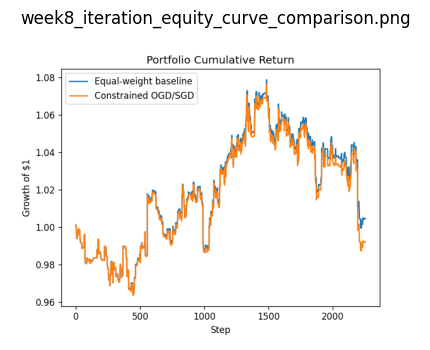

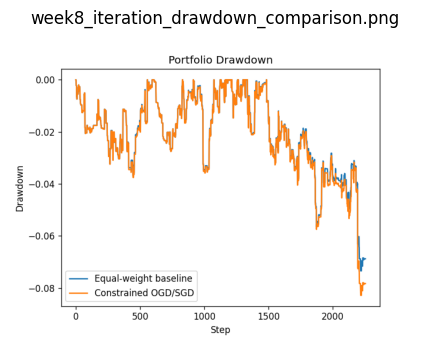

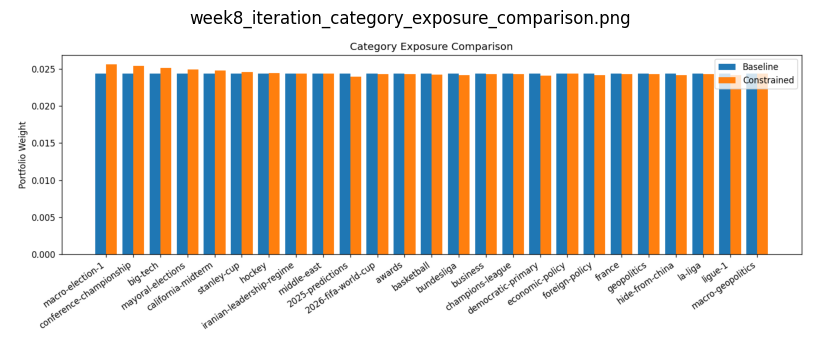

In [5]:
fig_paths = [
    figures / "week8_iteration_equity_curve_comparison.png",
    figures / "week8_iteration_drawdown_comparison.png",
    figures / "week8_iteration_category_exposure_comparison.png",
]
for fig_path in fig_paths:
    img = plt.imread(fig_path)
    plt.figure(figsize=(12, 4))
    plt.imshow(img)
    plt.title(fig_path.name)
    plt.axis("off")
    plt.show()
